# 04 · Improved ResNet-50 (proposed model)

This notebook trains two runs:

| Run | Ablation | Augmentation | Two-stage fine-tuning | LR scheduler |
|---|---|---|---|---|
| `resnet50_aug` | B | Yes | No | No |
| `proposed_resnet50` | C | Yes | Yes | Yes |

Ablation A is the ResNet-50 baseline from notebook 03.

## 1. Project folder

In [1]:
# Run this cell first, every time you open the notebook.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:                       # Google Colab
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/MalariaScanAI")  # where you unzipped the project
else:                                                   # your own laptop
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)

Project folder: c:\Users\VOTHY VYSAL\Documents\MalariaScanAI


## 2. Environment, GPU and dataset

In [2]:
from src.common import *

set_seed(42)
print_environment()

Python : 3.13.14
PyTorch: 2.14.1+cu126
CUDA available: True
Device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB
train images: 19363
val images: 4323
test images: 3872
Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']


## 3. Ablation B: ResNet-50 + augmentation

Same training as the baseline, plus augmentation on the training images only: horizontal and vertical flips, rotation by any angle, and small brightness and contrast changes.

**Why these are safe:** a blood cell has no "right way up", so flipping or rotating it never changes the label. Colour changes are kept small, because the parasite is recognised by its stain colour, and no cropping is used so a parasite near the edge is never cut out.

In [3]:
info_b = train("resnet50_aug", epochs=15, patience=3, batch_size=16)

resnet50_aug
Total parameters:         23,512,130
Trainable parameters:     23,512,130
Non-trainable parameters: 0

Epoch 1/15
Train Loss: 0.144
Train Accuracy: 95.07%
Val Loss: 0.179
Val Accuracy: 94.15%
Val Macro-F1: 93.93%
Time: 212.0 sec

Epoch 2/15
Train Loss: 0.104
Train Accuracy: 96.47%
Val Loss: 0.130
Val Accuracy: 95.14%
Val Macro-F1: 94.91%
Time: 209.5 sec

Epoch 3/15
Train Loss: 0.096
Train Accuracy: 96.73%
Val Loss: 0.125
Val Accuracy: 95.47%
Val Macro-F1: 95.26%
Time: 209.5 sec

Epoch 4/15
Train Loss: 0.091
Train Accuracy: 96.78%
Val Loss: 0.125
Val Accuracy: 95.37%
Val Macro-F1: 95.15%
Time: 207.2 sec

Epoch 5/15
Train Loss: 0.090
Train Accuracy: 96.89%
Val Loss: 0.123
Val Accuracy: 95.33%
Val Macro-F1: 95.12%
Time: 208.8 sec

Epoch 6/15
Train Loss: 0.086
Train Accuracy: 97.06%
Val Loss: 0.114
Val Accuracy: 95.77%
Val Macro-F1: 95.57%
Time: 208.2 sec

Epoch 7/15
Train Loss: 0.082
Train Accuracy: 97.13%
Val Loss: 0.158
Val Accuracy: 94.68%
Val Macro-F1: 94.47%
Time: 207.3 

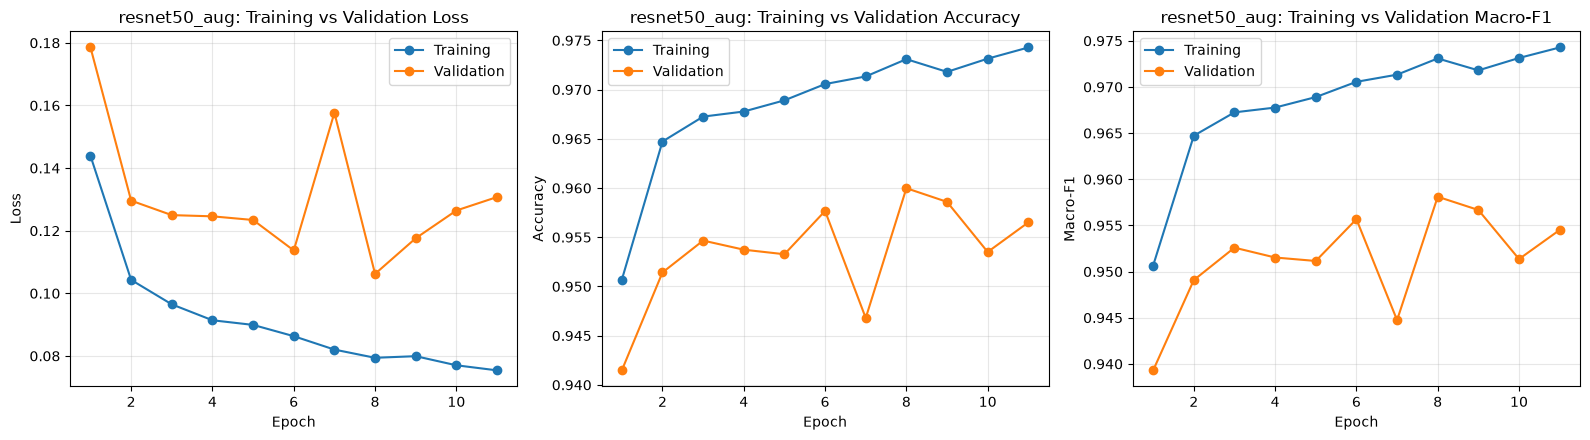

In [4]:
plot_history("resnet50_aug")

## 4. Ablation C: the proposed model

1. **Stage 1 (2 epochs):** freeze the pretrained network and train only the new classification head.
2. **Stage 2:** unfreeze `layer3` and `layer4` and fine-tune them with the head at a low learning rate, with a cosine learning-rate scheduler.

Early stopping, best-checkpoint saving and mixed precision are the same as before. The parameter counts are printed for both stages; stage 2 is the one that counts for the 10-million-trainable-parameter requirement.

In [5]:
info_c = train("proposed_resnet50", epochs=15, patience=3, batch_size=16, head_epochs=2)

proposed_resnet50, stage 1 (head only, 2 epochs)
Total parameters:         23,512,130
Trainable parameters:     4,098
Non-trainable parameters: 23,508,032

Epoch 1/15
Train Loss: 0.273
Train Accuracy: 89.94%
Val Loss: 0.289
Val Accuracy: 88.34%
Val Macro-F1: 88.02%
Time: 107.1 sec

Epoch 2/15
Train Loss: 0.203
Train Accuracy: 92.72%
Val Loss: 0.248
Val Accuracy: 90.79%
Val Macro-F1: 90.37%
Time: 105.7 sec

proposed_resnet50, stage 2 (fine-tune layer3 + layer4 + head)
Total parameters:         23,512,130
Trainable parameters:     22,067,202
Non-trainable parameters: 1,444,928

Epoch 3/15
Train Loss: 0.129
Train Accuracy: 95.73%
Val Loss: 0.145
Val Accuracy: 95.03%
Val Macro-F1: 94.79%
Time: 154.6 sec

Epoch 4/15
Train Loss: 0.103
Train Accuracy: 96.50%
Val Loss: 0.133
Val Accuracy: 95.17%
Val Macro-F1: 94.92%
Time: 157.1 sec

Epoch 5/15
Train Loss: 0.093
Train Accuracy: 96.87%
Val Loss: 0.192
Val Accuracy: 94.36%
Val Macro-F1: 94.14%
Time: 161.9 sec

Epoch 6/15
Train Loss: 0.088
Train A

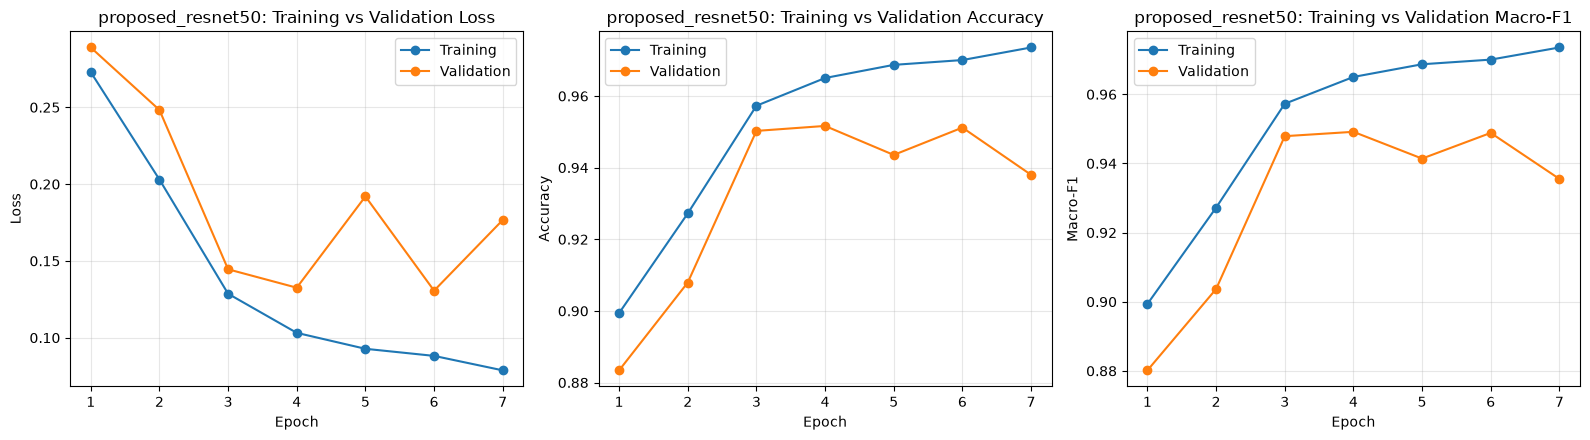

In [6]:
plot_history("proposed_resnet50")

## 5. Test results of the proposed model

In [ ]:
metrics, cm, classes, report = evaluate("proposed_resnet50")
for k in ("accuracy", "precision", "recall", "macro_f1"):
    print(f"Test {k}: {metrics[k] * 100:.2f}%")
print()
print(report)

Test accuracy: 96.95%
Test precision: 96.69%
Test recall: 96.86%
Test macro_f1: 96.78%

              precision    recall  f1-score   support

 PARASITIZED       0.96      0.96      0.96      1477
  UNINFECTED       0.98      0.97      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.97      0.97      0.97      3872
weighted avg       0.97      0.97      0.97      3872



: 